I first open the pickle files with the APE_paper environment and transform them to csvs. This is because of different pandas versions

In [12]:
import lecilab_behavior_analysis.utils as utils
import lecilab_behavior_analysis.df_transforms as dft
import lecilab_behavior_analysis.plots as plots
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pickle
import re


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# opto_df = pickle.load(open('/mnt/c/Users/HMARTINEZ/LeCiLab/data/behavioral_data/postdoc_data/Muscimol_dataframe.pkl', "rb"))
# opto_df.to_csv('/mnt/c/Users/HMARTINEZ/LeCiLab/data/behavioral_data/postdoc_data/Muscimol_dataframe.csv', index=False)

In [9]:
opto_df = pd.read_csv(Path(utils.get_outpath()) / "postdoc_data" / "6OHDA_dataframe.csv", index_col=0)

In [10]:
opto_df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,CenterPortDuration,TrialIndex,TrialHighPerc,Outcomes,FirstPokeCorrect,...,PreviousChoice,SessionID,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,PrevTrialSuccess
3326,C01,CortexBuffer,Jun11 14:58,2019-06-11 14:58:00,Auditory,0.1,6,2.0,1.0,1.0,...,1.0,C01 Jun11 14:58,3327,7.0,NaN,3,0.119801,5.3558,-0.02,1.0
3327,C01,CortexBuffer,Jun11 14:58,2019-06-11 14:58:00,Auditory,0.1,7,98.0,1.0,1.0,...,2.0,C01 Jun11 14:58,3328,8.0,NaN,4,0.115000,18.0093,-0.02,1.0
3328,C01,CortexBuffer,Jun11 14:58,2019-06-11 14:58:00,Auditory,0.1,8,98.0,1.0,1.0,...,1.0,C01 Jun11 14:58,3329,9.0,NaN,1,0.147099,10.1849,-0.02,1.0
3329,C01,CortexBuffer,Jun11 14:58,2019-06-11 14:58:00,Auditory,0.1,9,2.0,3.0,0.0,...,1.0,C01 Jun11 14:58,3330,10.0,NaN,2,0.105000,2.2890,-0.02,1.0
3330,C01,CortexBuffer,Jun11 14:58,2019-06-11 14:58:00,Auditory,0.1,10,98.0,1.0,0.0,...,NaN,C01 Jun11 14:58,3331,11.0,NaN,1,0.101700,NaN,-0.02,NaN


In [11]:
opto_df.columns

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'CenterPortDuration', 'TrialIndex', 'TrialHighPerc',
       'Outcomes', 'FirstPokeCorrect', 'FirstPoke', 'TrialSide',
       'TrialSequence', 'ResponseTime', 'TrialStartTimestamp',
       'CumulativePerformance', 'SwitchSide', 'PreviousChoice', 'SessionID',
       'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance100', 'NoOfCenterPokes', 'MiddleWaitTime',
       'TrialInitiationTime', 'RightBias', 'PrevTrialSuccess'],
      dtype='object')

In [5]:
# only for the muscimol dataset
sessionIDs_tokeep = ['pdyn01 Sep30 14:46', 'pdyn01 Sep30 14:52',
       'pdyn01 Oct01 15:53', 'pdyn01 Oct02 16:16', 'pdyn01 Oct03 14:27',
       'pdyn01 Oct08 14:48', 'pdyn01 Oct09 13:32', 'pdyn01 Oct10 13:43',
       'pdyn01 Oct11 15:09', 'pdyn01 Oct14 15:10', 'pdyn01 Oct15 14:57',
       'pdyn01 Oct16 14:27', 'pdyn01 Oct17 13:52', 'pdyn01 Oct18 12:55',
       'pdyn01 Oct21 14:20', 'pdyn01 Oct22 13:45', 'pdyn01 Oct23 13:48',
       'pdyn01 Oct24 14:09', 'pdyn03 Sep30 14:46',
       'pdyn03 Sep30 14:53', 'pdyn03 Oct01 15:47', 'pdyn03 Oct02 16:17',
       'pdyn03 Oct03 14:25', 'pdyn03 Oct08 14:53', 'pdyn03 Oct09 16:13',
       'pdyn03 Oct10 13:47', 'pdyn03 Oct11 15:42', 'pdyn03 Oct14 15:06',
       'pdyn03 Oct15 15:28', 'pdyn03 Oct16 14:27', 'pdyn03 Oct17 14:18',
       'pdyn03 Oct18 12:56', 'pdyn03 Oct21 14:25', 'pdyn03 Oct22 14:14',
       'pdyn03 Oct23 14:16', 'pdyn03 Oct24 14:32', 'pdyn04 Oct01 15:50',
       'pdyn04 Oct02 16:17', 'pdyn04 Oct03 14:25', 'pdyn04 Oct08 14:50',
       'pdyn04 Oct09 16:42', 'pdyn04 Oct10 13:46', 'pdyn04 Oct11 16:32',
       'pdyn04 Oct14 15:13', 'pdyn04 Oct15 16:13', 'pdyn04 Oct16 14:26',
       'pdyn04 Oct17 14:58', 'pdyn04 Oct18 12:57', 'pdyn04 Oct21 14:25',
       'pdyn04 Oct22 14:41', 'pdyn04 Oct23 14:43', 'pdyn04 Oct24 14:47',
       'T01 May16 13:55', 'T01 May17 13:50', 'T01 May20 15:16',
       'T01 May21 15:12', 'T01 May22 16:48', 'T01 May23 13:55',
       'T01 May24 16:03', 'T01 May25 12:50', 'T01 May26 17:54',
       'T01 May27 18:12', 'T01 May28 14:33', 'T01 May29 15:48',
       'T01 May30 14:40', 'T01 May31 10:25', 'T03 May16 13:55', 'T03 May17 13:50', 'T03 May20 15:16',
       'T03 May21 16:41', 'T03 May22 16:56', 'T03 May23 13:56',
       'T03 May24 16:06', 'T03 May25 13:00', 'T03 May26 18:11',
       'T03 May27 18:37', 'T03 May28 14:35', 'T03 May29 16:15',
       'T03 May30 14:42', 'T03 May31 10:43'
    
]
opto_df = opto_df[opto_df.SessionID.isin(sessionIDs_tokeep)]

In [13]:
def convert_postdoc_df_to_current_format(df):
    """
    Converts data from old format to new format.

    Old format columns:
    ['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
    'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
    'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
    'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
    'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
    'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
    'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
    'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
    'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
    'CurrentPastPerformance20', 'CurrentPastPerformance100',
    'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
    'TrialsSpeed', 'PrevTrialSuccess']

    New format columns:
    ['session', 'date', 'trial', 'subject', 'task', 'system_name',
    'run_mode', 'Port1In', 'Port1Out', 'Port2In', 'Port2Out', 'Port3In',
    'Port3Out', 'STATE_auto_reward_state_left_END',
    'STATE_auto_reward_state_left_START', 'STATE_hold_center_port_END',
    'STATE_hold_center_port_START', 'STATE_hold_while_stimulus_END',
    'STATE_hold_while_stimulus_START', 'STATE_iti_END', 'STATE_iti_START',
    'STATE_punish_state_END', 'STATE_punish_state_START',
    'STATE_ready_to_initiate_END', 'STATE_ready_to_initiate_START',
    'STATE_reward_state_END', 'STATE_reward_state_START',
    'STATE_reward_state_left_END', 'STATE_reward_state_left_START',
    'STATE_reward_state_right_END', 'STATE_reward_state_right_START',
    'STATE_start_of_trial_END', 'STATE_start_of_trial_START',
    'STATE_stimulus_state_END', 'STATE_stimulus_state_START', 'TRIAL_END',
    'TRIAL_START', 'Tup', 'auditory_real_statistics', 'auditory_stimulus',
    'correct', 'correct_side', 'current_training_stage', 'difficulty',
    'holding_time', 'ordered_list_of_events', 'stimulus_modality',
    'stimulus_modality_block_number', 'visual_stimulus', 'water']
    """
    old_df = df.copy()
    # # get center port duration
    # old_df["holding_time"] = pd.Series([eval(old_df.iloc[x].FullGUI)['CenterPortDuration'] for x in range(0, old_df.shape[0])])

    # transform TrialSequence to "easy"...
    old_df["difficulty"] = old_df.TrialSequence.map({1: "easy", 2: "medium", 3: "hard", 4: "impossible", 5: "hard", 6: "medium", 7: "easy"})
    
    # fill the info for the port events
    def string_to_dict(s):
        # remove dtype=... fragments
        s = re.sub(r",\s*dtype\s*=\s*[^)\]]+", "", s)
        tree = ast.parse(s, mode="eval")
        return eval(
            compile(tree, "<string>", "eval"),
            {"__builtins__": {}},          # no builtins → safer
            {"array": np.array, "nan": np.nan},            # allow array(...)
        )
    def dict_to_lists(trial_events_str):
        trial_events = string_to_dict(trial_events_str)
        lists_to_return = [[], [], [], [], [], []]
        for i, ev in enumerate(['Port1In', 'Port1Out', 'Port2In', 'Port2Out', 'Port3In', 'Port3Out']): 
            if ev in trial_events:
                lists_to_return[i] = trial_events[ev]
                try:
                    lists_to_return[i] = list(lists_to_return[i]) # convert to list if it's an array
                except:
                    lists_to_return[i] = [lists_to_return[i]] # if it's a scalar, put it in a list
        
        return lists_to_return[0], lists_to_return[1], lists_to_return[2], lists_to_return[3], lists_to_return[4], lists_to_return[5]
    
    old_df["lists_returned"] = old_df.TrialEvents.apply(dict_to_lists)
    old_df["Port1In"], old_df["Port1Out"], old_df["Port2In"], old_df["Port2Out"], old_df["Port3In"], old_df["Port3Out"] = zip(*old_df.lists_returned)
    # remove lists_returned column
    old_df = old_df.drop(columns=["lists_returned"])
    # add the TrialStartTimestamp to the port events to get absolute timestamps
    for port in ['Port1In', 'Port1Out', 'Port2In', 'Port2Out', 'Port3In', 'Port3Out']:
        old_df[port] = old_df.apply(lambda row: [t + row.TrialStartTimestamp for t in row[port]], axis=1)

    # get ordered list of events
    def keys_by_time(d):
        d = string_to_dict(d) # convert string to dict
        events = [] 
        for key, val in d.items():
            # handle arrays / lists
            if isinstance(val, (list, tuple, np.ndarray)):
                for t in val:
                    events.append((float(t), key))
            else:  # handle scalar
                events.append((float(val), key))
        # sort by time
        events.sort(key=lambda x: x[0]) 
        # return keys in time order
        return [key for _, key in events]
    
    old_df["ordered_list_of_events"] = old_df.TrialEvents.apply(keys_by_time)

    # FirstPokeCorrect to true false
    old_df["correct"] = old_df["FirstPokeCorrect"].map({1: True, 0: False})

    # CorrectSide to left right
    old_df["correct_side"] = old_df["TrialSide"].map({1: "left", 2: "right"})

    # information about states and end of trial
    def get_end_of_trial(trial_states_str):
        trial_states = string_to_dict(trial_states_str)
        # find the largest timestamp
        max_time = 0
        for _, times in trial_states.items():
            # times can be an array of 2-size lists
            times = times.flatten()
            max_time = max(max_time, max(times))
        return max_time
    old_df["TRIAL_END"] = old_df.TrialStates.apply(get_end_of_trial)
    # add the TrialStartTimestamp as TRIAL_START
    old_df["TRIAL_END"] = old_df["TRIAL_END"] + old_df["TrialStartTimestamp"]

    # get information about STATE_stimulus_state, equivalent to WaitForResponse
    def get_STATE_stimulus_state(trial_states_str):
        trial_states = string_to_dict(trial_states_str)
        wfr = trial_states.get("WaitForResponse")
        return wfr
    old_df["STATE_stimulus_state"] = old_df.TrialStates.apply(get_STATE_stimulus_state)
    old_df["STATE_stimulus_state_START"] = old_df.apply(lambda row: [row.STATE_stimulus_state[0] + row.TrialStartTimestamp], axis=1)
    old_df["STATE_stimulus_state_END"] = old_df.apply(lambda row: [row.STATE_stimulus_state[1] + row.TrialStartTimestamp], axis=1)
    old_df.drop(columns=["STATE_stimulus_state"], inplace=True)
    
    # get information about STATE_ready_to_initiate_START, equivalent toWaitForPoke
    def get_state_ready_to_initiate(trial_states_str):
        trial_states = string_to_dict(trial_states_str)
        wfp = trial_states.get("WaitForPoke")
        return wfp
    old_df["STATE_ready_to_initiate"] = old_df.TrialStates.apply(get_state_ready_to_initiate)
    old_df["STATE_ready_to_initiate_START"] = old_df.apply(lambda row: [row.STATE_ready_to_initiate[0] + row.TrialStartTimestamp], axis=1)
    old_df["STATE_ready_to_initiate_END"] = old_df.apply(lambda row: [row.STATE_ready_to_initiate[1] + row.TrialStartTimestamp], axis=1)
    old_df.drop(columns=["STATE_ready_to_initiate"], inplace=True)

    # add stimulus modality
    old_df["stimulus_modality"] = old_df.Protocol.map({"Auditory": "auditory",
                                                       "Visual": "visual",
                                                       "Aud_Psycho": "auditory",
                                                       })

    # rename columns
    new_df = old_df.rename(columns={
        "AnimalID": "subject",
        "FullSessionTime": "date",
        "TrialStartTimestamp": "TRIAL_START",
        "TrialIndex": "trial",
        "CenterPortDuration": "holding_time",
        })
    
    return new_df

In [14]:
# test the function
new_opto_df = convert_postdoc_df_to_current_format(opto_df)

AttributeError: 'DataFrame' object has no attribute 'TrialEvents'

In [33]:
# test the analysis
df_analyzed= dft.analyze_df(new_opto_df)

In [34]:
# save it as a pickle
df_analyzed.to_pickle(Path(utils.get_outpath()) / "postdoc_data" / "Muscimol_dataframe_converted.pkl")

In [188]:
df_analyzed.head()

,subject,ExperimentalGroup,SessionTime,date,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,STATE_ready_to_initiate_END,stimulus_modality,current_training_stage,year_month_day,miss_trial,first_choice,last_choice,early_pokeout,total_trial,trial_of_day
0,D1opto-01,optoinhibition,Jul13 13:25,2021-07-13 13:25:00,Auditory,NoStimulation,No,No,0,0.03,...,[287.6149],auditory,not saved,2021-07-13,False,right,left,False,1.0,1
1,D1opto-01,optoinhibition,Jul13 13:25,2021-07-13 13:25:00,Auditory,NoStimulation,No,No,0,0.03,...,[308.40029999999996],auditory,not saved,2021-07-13,False,right,right,False,2.0,2
2,D1opto-01,optoinhibition,Jul13 13:25,2021-07-13 13:25:00,Auditory,NoStimulation,No,No,0,0.03,...,[344.8307],auditory,not saved,2021-07-13,False,right,left,False,3.0,5
3,D1opto-01,optoinhibition,Jul13 13:25,2021-07-13 13:25:00,Auditory,NoStimulation,No,No,0,0.03,...,[350.91110000000003],auditory,not saved,2021-07-13,False,left,left,False,4.0,6
4,D1opto-01,optoinhibition,Jul13 13:25,2021-07-13 13:25:00,Auditory,NoStimulation,No,No,0,0.03,...,[352.53],auditory,not saved,2021-07-13,False,right,left,False,5.0,7


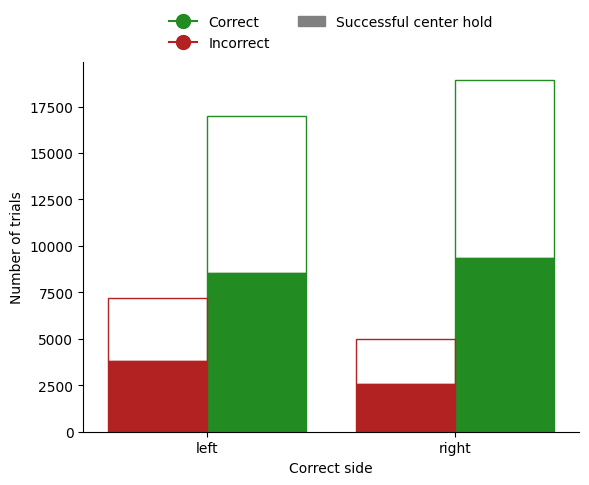

In [35]:
plots.number_of_correct_responses_plot(df_analyzed)
plt.show()

Analysis for the D1/D2 optostimulation

In [194]:
# select only sessions with optogenetic stimulation
session_with_opto = []

for date in df_analyzed.date.unique():
    df_date = df_analyzed[df_analyzed.date == date]
    if df_date.OptoStim.sum() > 0: # if there is at least one trial with opto stimulation
        session_with_opto.append(date)

In [195]:
df_wo = df_analyzed[df_analyzed.date.isin(session_with_opto)]

In [197]:
df_wo.groupby("Protocol").OptoStim.value_counts()

Protocol    OptoStim
Aud_Psycho  0.0         40417
            1.0          9869
Auditory    0.0          6219
            1.0           734
Visual      0.0          6407
            1.0          1158
Name: count, dtype: int64

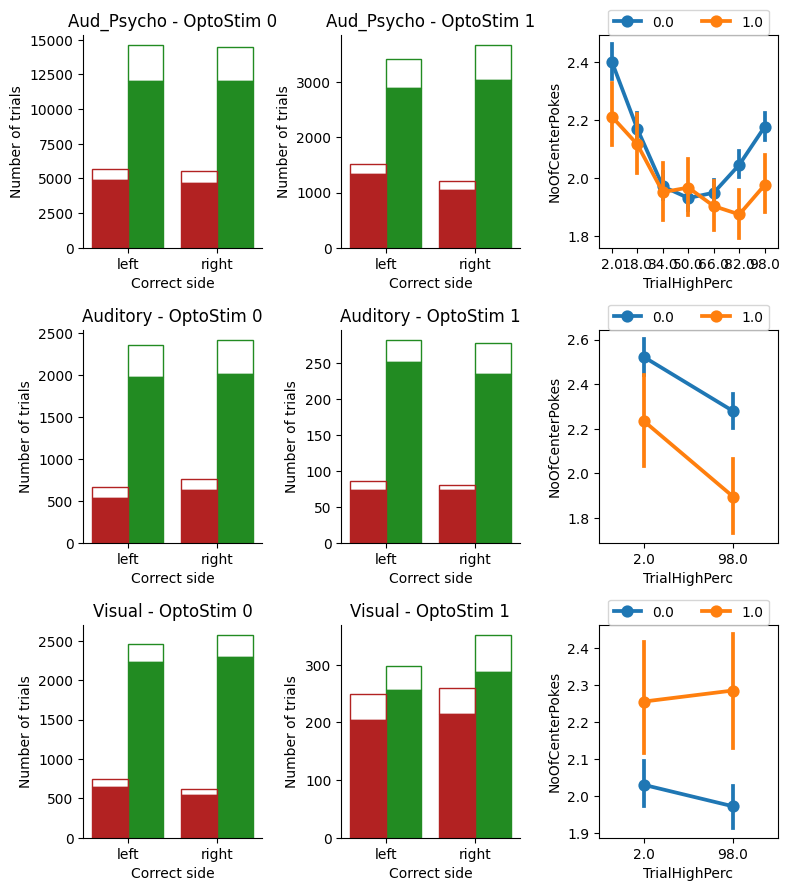

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(8, 9))

for k, protocol in enumerate(df_wo.Protocol.unique()):

    for i, opto_condition in enumerate([0, 1]):
        df_subset = df_wo[(df_wo.Protocol == protocol) & (df_wo.OptoStim == opto_condition)]
        axs[k, i] = plots.number_of_correct_responses_plot(df_subset, ax=axs[k, i])
        axs[k, i].set_title(f"{protocol} - OptoStim {opto_condition}")
    # remove legend
    axs[k, 0].get_legend().remove()
    # reduce size of legend
    axs[k, 1].get_legend().remove()
    sns.pointplot(data=df_wo[df_wo.Protocol == protocol], x='TrialHighPerc', y='NoOfCenterPokes', hue='OptoStim', ax=axs[k, 2])
    # legend on top
    axs[k, 2].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

Analysis for the muscimol

careful, as three animals (pdyn) have 0.1 waiting time and no TS-control

In [40]:
df_analyzed.groupby("subject")["Muscimol"].value_counts()

subject  Muscimol             
T01      StrTail-bilat            2770
         No                       2465
         AUD1-bilat               2112
         StrTail-bilat-Control    1382
         AUD1-bilat-Control       1190
         StrTail-right             314
T03      StrTail-bilat            2387
         AUD1-bilat               2236
         No                       1970
         StrTail-bilat-Control    1758
         AUD1-bilat-Control       1622
         StrTail-left              168
pdyn01   No                       7170
         StrTail-bilat            1891
         DMS-bilat                 904
         NAc                       792
pdyn03   No                       6429
         DMS-bilat                1098
         StrTail-bilat             951
pdyn04   No                       6243
         DMS-bilat                1518
         StrTail-bilat            1371
Name: count, dtype: int64

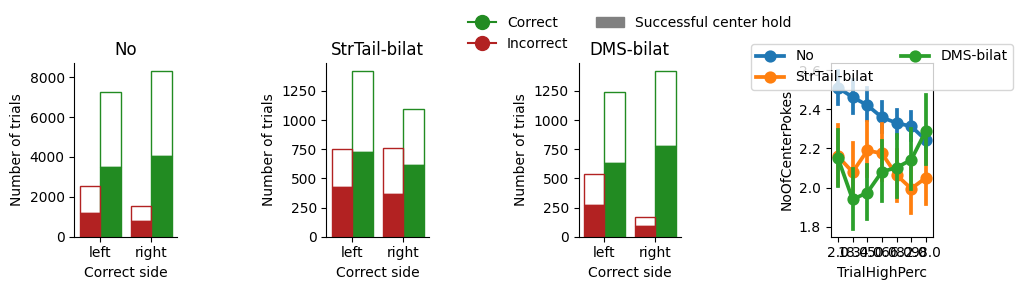

In [42]:
df_to_show = df_analyzed[df_analyzed.subject.isin(["pdyn01", "pdyn03", "pdyn04"])].copy()
df_to_show = df_to_show[df_to_show.Muscimol.isin(["No", "StrTail-bilat", "DMS-bilat"])]

fig, axs = plt.subplots(1, 4, figsize=(10, 3))

for i, muscimol in enumerate(df_to_show.Muscimol.unique()):
    df_subset = df_to_show[df_to_show.Muscimol == muscimol]
    axs[i] = plots.number_of_correct_responses_plot(df_subset, ax=axs[i])
    axs[i].set_title(f"{muscimol}")
# remove legend
axs[0].get_legend().remove()
# reduce size of legend
axs[1].get_legend().remove()
sns.pointplot(data=df_to_show, x='TrialHighPerc', y='NoOfCenterPokes', hue='Muscimol', ax=axs[3])
# legend on top
axs[3].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

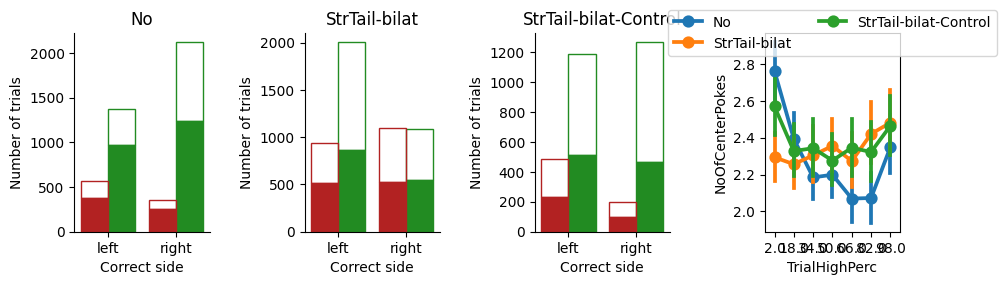

In [44]:
df_to_show = df_analyzed[df_analyzed.subject.isin(["T01", "T03"])].copy()
df_to_show = df_to_show[df_to_show.Muscimol.isin(["No", "StrTail-bilat", "StrTail-bilat-Control"])]

fig, axs = plt.subplots(1, 4, figsize=(10, 3))

for i, muscimol in enumerate(df_to_show.Muscimol.unique()):
    df_subset = df_to_show[df_to_show.Muscimol == muscimol]
    axs[i] = plots.number_of_correct_responses_plot(df_subset, ax=axs[i])
    axs[i].set_title(f"{muscimol}")
# remove legend
axs[0].get_legend().remove()
# reduce size of legend
axs[1].get_legend().remove()
axs[2].get_legend().remove()
sns.pointplot(data=df_to_show, x='TrialHighPerc', y='NoOfCenterPokes', hue='Muscimol', ax=axs[3])
# legend on top
axs[3].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()

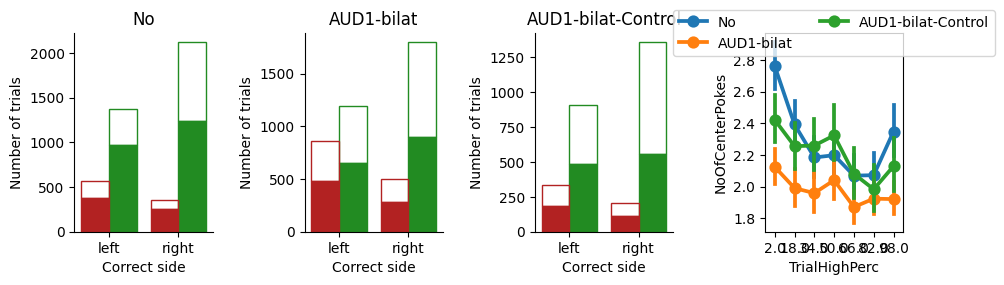

In [45]:
df_to_show = df_analyzed[df_analyzed.subject.isin(["T01", "T03"])].copy()
df_to_show = df_to_show[df_to_show.Muscimol.isin(["No", "AUD1-bilat", "AUD1-bilat-Control"])]

fig, axs = plt.subplots(1, 4, figsize=(10, 3))

for i, muscimol in enumerate(df_to_show.Muscimol.unique()):
    df_subset = df_to_show[df_to_show.Muscimol == muscimol]
    axs[i] = plots.number_of_correct_responses_plot(df_subset, ax=axs[i])
    axs[i].set_title(f"{muscimol}")
# remove legend
axs[0].get_legend().remove()
# reduce size of legend
axs[1].get_legend().remove()
axs[2].get_legend().remove()
sns.pointplot(data=df_to_show, x='TrialHighPerc', y='NoOfCenterPokes', hue='Muscimol', ax=axs[3])
# legend on top
axs[3].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.tight_layout()
plt.show()